# 125M1H026_ADS_Ex_Lab_T1_A2
## Retail Sales Dashboard

This notebook uses the provided `sales.csv` file to prepare and analyse the retail sales data.  
The final section contains the Streamlit application code for the dashboard.

The dashboard covers:
- dataset loading and preview
- mean and median of daily revenue
- total units sold and revenue by product category
- daily revenue trend
- revenue comparison across product categories


## 1. Import libraries

Pandas is used for data handling and Matplotlib is used for the charts.  
The Streamlit import is included later for the web application.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the dataset

The file is read first so the column names and data types can be checked before doing any calculations.

In [2]:
sales_data = pd.read_csv("./data/sales.csv")

sales_data.head()

,Date,StoreID,ProductCategory,UnitsSold,Revenue,Cost
0,2023-01-01,S2,Clothing,19,879.70,130.31
1,2023-01-02,S2,Clothing,3,408.06,198.29
2,2023-01-03,S2,Electronics,11,760.66,439.35
3,2023-01-04,S2,Clothing,9,654.45,340.31
4,2023-01-05,S2,Clothing,1,249.59,214.99


In [3]:
print("Dataset shape:", sales_data.shape)
print("\nColumn data types:")
print(sales_data.dtypes)
print("\nMissing values:")
print(sales_data.isnull().sum())
print("\nDuplicate rows:", sales_data.duplicated().sum())

Dataset shape: (100, 6)

Column data types:
Date                   str
StoreID                str
ProductCategory        str
UnitsSold            int64
Revenue            float64
Cost               float64
dtype: object

Missing values:
Date               0
StoreID            0
ProductCategory    0
UnitsSold          0
Revenue            0
Cost               0
dtype: int64

Duplicate rows: 0


### Dataset observations

The provided dataset contains 100 records and 6 columns:

- `Date`
- `StoreID`
- `ProductCategory`
- `UnitsSold`
- `Revenue`
- `Cost`

The data has no missing values and no duplicate rows. The `Date` column is converted to datetime format before time-based analysis.

In [4]:
sales_data["Date"] = pd.to_datetime(sales_data["Date"])

print("Date range:", sales_data["Date"].min().date(), "to", sales_data["Date"].max().date())
print("\nProduct categories:")
print(sales_data["ProductCategory"].value_counts())

Date range: 2023-01-01 to 2023-04-10

Product categories:
ProductCategory
Electronics    42
Clothing       31
Groceries      27
Name: count, dtype: int64


## 3. Preview the retail sales data

A small preview is useful in the dashboard so the user can confirm that the correct dataset has been loaded.

In [5]:
sales_data.head(10)

,Date,StoreID,ProductCategory,UnitsSold,Revenue,Cost
0,2023-01-01,S2,Clothing,19,879.70,130.31
1,2023-01-02,S2,Clothing,3,408.06,198.29
2,2023-01-03,S2,Electronics,11,760.66,439.35
3,2023-01-04,S2,Clothing,9,654.45,340.31
4,2023-01-05,S2,Clothing,1,249.59,214.99
5,2023-01-06,S2,Clothing,12,544.00,597.01
6,2023-01-07,S3,Groceries,13,832.85,473.17
7,2023-01-08,S1,Clothing,16,750.60,480.62
8,2023-01-09,S3,Electronics,17,940.18,590.50
9,2023-01-10,S2,Groceries,5,816.13,138.61


## 4. Calculate summary statistics for daily revenue

The required statistics are the mean and median of the `Revenue` column.

In [6]:
mean_daily_revenue = sales_data["Revenue"].mean()
median_daily_revenue = sales_data["Revenue"].median()

print(f"Mean daily revenue: {mean_daily_revenue:.2f}")
print(f"Median daily revenue: {median_daily_revenue:.2f}")

Mean daily revenue: 559.84
Median daily revenue: 550.98


## 5. Group sales by product category

The data is grouped by `ProductCategory`. For each category, the total units sold and total revenue are calculated.

In [7]:
category_summary = (
    sales_data.groupby("ProductCategory")[["UnitsSold", "Revenue"]]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

category_summary

,ProductCategory,UnitsSold,Revenue
1,Electronics,425,24165.45
0,Clothing,295,16681.11
2,Groceries,256,15137.83


## 6. Plot the daily revenue trend

The line chart shows how revenue changes across the available dates.

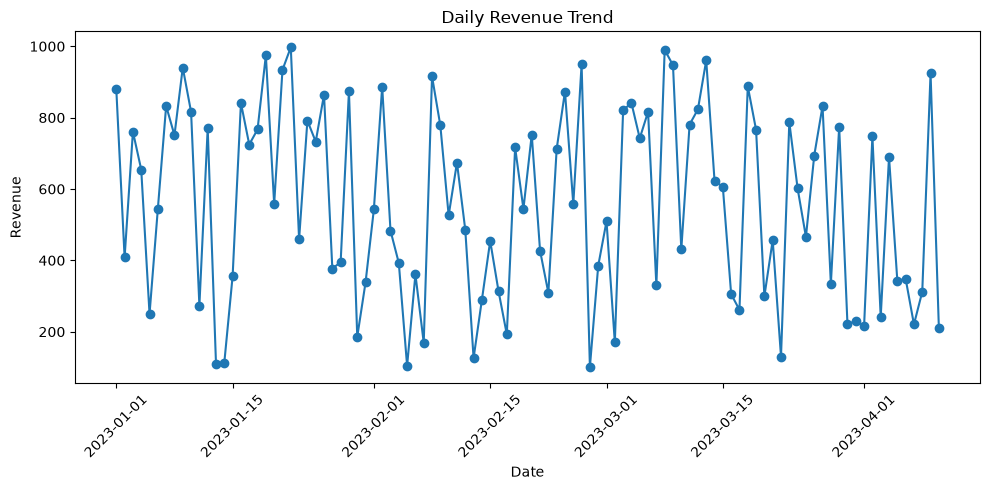

In [8]:
daily_revenue = sales_data.groupby("Date")["Revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(daily_revenue["Date"], daily_revenue["Revenue"], marker="o")
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Compare revenue across product categories

A bar chart makes the total revenue of each product category easier to compare.

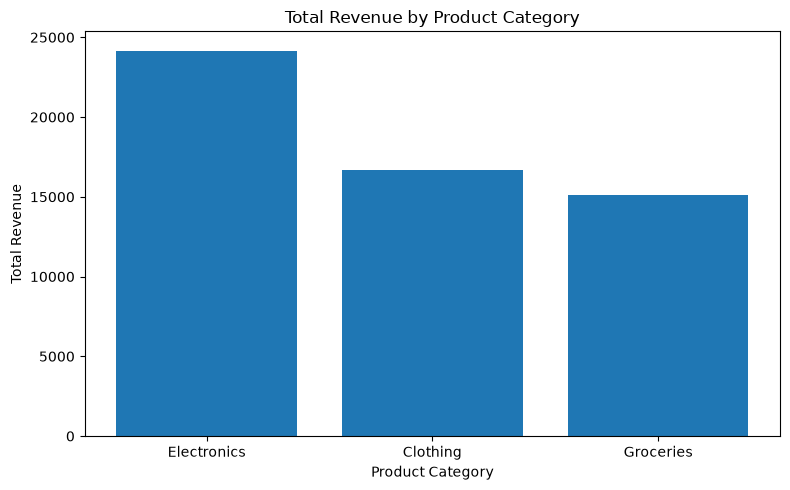

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(category_summary["ProductCategory"], category_summary["Revenue"])
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

# Streamlit Web Application

The code below implements the required dashboard. Save it as `T1_app.py` in the same folder as `125M1H026_ADS_Ex_Lab_T1_A2`.

Run the application with:

`streamlit run T1_app.py`
or 
`python -m streamlit run .\T1_app.py`

The app includes all required features from the task.

## Conclusion

The dashboard loads the provided retail sales data and presents the main information required for the assignment. It shows a preview of the data, revenue statistics, product category totals, the daily revenue trend, and a category-wise revenue comparison.